In [13]:
## 1. IMPORT LIBRARIES

import pandas as pd               # Data manipulation and dataframes
import numpy as np                # Numerical computations
import matplotlib.pyplot as plt   # Plotting charts and graphs
import seaborn as sns             # Higher-level visualization built on matplotlib

from sklearn.ensemble import RandomForestRegressor  # Random Forest regression model

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
# TimeSeriesSplit  : cross-validation that respects time order (no future leakage)
# RandomizedSearchCV: randomly samples hyperparameter combos to find the best config

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# mean_absolute_error : average of |actual - predicted|
# mean_squared_error  : average of (actual - predicted)^2, penalizes large errors more
# r2_score            : coefficient of determination, measures how well the model fits the data

from sklearn.preprocessing import LabelEncoder
# LabelEncoder: converts text categories (e.g. "BLOOR STATION") into integers

import shap  # SHapley Additive exPlanations — explains which features drive predictions

In [14]:
## 2. LOAD AND PREVIEW DATA

#Read the combined TTC subway delay CSV into a DataFrame
df = pd.read_csv("../data/processed/ttc_subway_delay_data_weather_obt.csv")

# Print number of rows and columns to confirm it loaded correctly
print(df.shape)

# Print each column name and its data type
print(df.dtypes)

# Preview the first 5 rows
print(df.head())

# Check for missing values in each column
print(df.isnull().sum())

(24389, 60)
date                       str
time                       str
day                        str
station                    str
code                       str
delayed_minutes          int64
gap_minutes              int64
bound                      str
line                       str
vehicle                  int64
year                     int64
datetime                   str
hour                     int64
weekday                  int64
is_weekend               int64
month                    int64
week                     int64
peak_hour                int64
mapped_station             str
station_score            int64
include_station        float64
station_remarks            str
delay_code                 str
mapped_delay_code          str
fuzzy_score              int64
include_code           float64
delay_code_remarks         str
line_clean                 str
bound_clean                str
Longitude (x)          float64
Latitude (y)           float64
Station Name               

C:\Users\lll02\AppData\Local\Temp\ipykernel_49868\1365309089.py:4: DtypeWarning: Columns (0: delay_code_remarks, 1: Temp Flag, 2: Dew Point Temp Flag, 3: Rel Hum Flag, 4: Stn Press Flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/ttc_subway_delay_data_weather_obt.csv")


In [15]:
## 3. DATA CLEANING AND PREPARATION

# Convert the 'date' column from string to a proper datetime object
# errors='coerce' turns any unparseable values into NaT instead of crashing
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Combine the 'date' and 'time' columns into a single datetime column
# This gives us a precise timestamp for each delay event (e.g. 2024-01-01 08:35:00)
df['datetime'] = pd.to_datetime(df['datetime'] , errors='coerce')

df = df.dropna(subset=['datetime'])

# Sort all rows in chronological order — required for time series splitting
# Without this, TimeSeriesSplit would not work correctly
df = df.sort_values('datetime').reset_index(drop=True)

# Preview the first 5 rows
print(df.head())

# Check for missing values in each column again after cleaning
print(df.isnull().sum())

        date   time     day  ... Wind Chill Wind Chill Flag  Weather
0 2023-01-01  02:22  Sunday  ...        NaN             NaN      NaN
1 2023-01-01  08:44  Sunday  ...        NaN             NaN      NaN
2 2023-01-01  08:38  Sunday  ...        NaN             NaN      NaN
3 2023-01-01  08:02  Sunday  ...        NaN             NaN      NaN
4 2023-01-01  08:11  Sunday  ...        NaN             NaN      NaN

[5 rows x 60 columns]
date                       0
time                       0
day                        0
station                    0
code                       0
delayed_minutes            0
gap_minutes                0
bound                    298
line                       1
vehicle                    0
year                       0
datetime                   0
hour                       0
weekday                    0
is_weekend                 0
month                      0
week                       0
peak_hour                  0
mapped_station             0
station_scor

In [16]:
## 4. ENCODE CATEGORICAL FEATURES

# List of columns that contain text categories
# sklearn's API requires numeric input arrays, so we must convert these
cat_cols = ['station', 'code', 'bound', 'line', 'day']

# Create a LabelEncoder instance — reused for each column
le = LabelEncoder()

# Loop through each categorical column and create a new encoded version
# e.g. 'BLOOR STATION' → 3, 'DUNDAS STATION' → 7, etc.
# We keep the originals in case we need them for inspection later
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))


# Preview the first 5 rows
df.head()

,date,time,day,station,code,delayed_minutes,gap_minutes,bound,line,vehicle,year,datetime,hour,weekday,is_weekend,month,week,peak_hour,mapped_station,station_score,include_station,station_remarks,delay_code,mapped_delay_code,fuzzy_score,include_code,delay_code_remarks,line_clean,bound_clean,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time (LST),Year,Month,Day,Time (LST),Flag,Temp (°C),Temp Flag,Dew Point Temp (°C),Dew Point Temp Flag,Rel Hum (%),Rel Hum Flag,Precip. Amount (mm),Precip. Amount Flag,Wind Dir (10s deg),Wind Dir Flag,Wind Spd (km/h),Wind Spd Flag,Visibility (km),Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather,station_enc,code_enc,bound_enc,line_enc,day_enc
0,2023-01-01,02:22,Sunday,MUSEUM STATION,MUPAA,3,9,S,YU,5931,2023,2023-01-01 02:00:00,2,6,1,1,52,0,Museum,100,1.0,NaN,MUPAA,MUPAA,100,1.0,NaN,Yonge-University,S,-79.4,43.63,TORONTO CITY CENTRE,6158359,2023-01-01 02:00:00,2023,1,1,02:00,NaN,3.7,NaN,1.7,NaN,87.0,NaN,0.0,NaN,28.0,NaN,17.0,NaN,16.1,NaN,100.27,NaN,NaN,NaN,NaN,NaN,NaN,131,72,3,4,3
1,2023-01-01,08:44,Sunday,SHEPPARD WEST STATION,TUNOA,6,12,N,YU,5851,2023,2023-01-01 08:00:00,8,6,1,1,52,1,Sheppard West,100,1.0,NaN,TUNOA,TUNOA,100,1.0,NaN,Yonge-University,N,-79.4,43.63,TORONTO CITY CENTRE,6158359,2023-01-01 08:00:00,2023,1,1,08:00,NaN,3.8,NaN,-0.5,NaN,74.0,NaN,0.0,NaN,29.0,NaN,18.0,NaN,16.1,NaN,100.54,NaN,NaN,NaN,NaN,NaN,NaN,162,156,2,4,3
2,2023-01-01,08:38,Sunday,EGLINTON STATION,TUNOA,6,12,N,YU,6131,2023,2023-01-01 08:00:00,8,6,1,1,52,1,Eglinton,100,1.0,NaN,TUNOA,TUNOA,100,1.0,NaN,Yonge-University,N,-79.4,43.63,TORONTO CITY CENTRE,6158359,2023-01-01 08:00:00,2023,1,1,08:00,NaN,3.8,NaN,-0.5,NaN,74.0,NaN,0.0,NaN,29.0,NaN,18.0,NaN,16.1,NaN,100.54,NaN,NaN,NaN,NaN,NaN,NaN,48,156,2,4,3
3,2023-01-01,08:02,Sunday,VAUGHAN MC STATION,TUNOA,6,12,S,YU,5451,2023,2023-01-01 08:00:00,8,6,1,1,52,1,Vaughan,95,1.0,NaN,TUNOA,TUNOA,100,1.0,NaN,Yonge-University,S,-79.4,43.63,TORONTO CITY CENTRE,6158359,2023-01-01 08:00:00,2023,1,1,08:00,NaN,3.8,NaN,-0.5,NaN,74.0,NaN,0.0,NaN,29.0,NaN,18.0,NaN,16.1,NaN,100.54,NaN,NaN,NaN,NaN,NaN,NaN,228,156,3,4,3
4,2023-01-01,08:11,Sunday,GREENWOOD STATION,MUNOA,5,10,E,BD,0,2023,2023-01-01 08:00:00,8,6,1,1,52,1,Greenwood,100,1.0,NaN,MUNOA,MUNOA,100,1.0,NaN,Bloor-Danforth,E,-79.4,43.63,TORONTO CITY CENTRE,6158359,2023-01-01 08:00:00,2023,1,1,08:00,NaN,3.8,NaN,-0.5,NaN,74.0,NaN,0.0,NaN,29.0,NaN,18.0,NaN,16.1,NaN,100.54,NaN,NaN,NaN,NaN,NaN,NaN,70,70,1,0,3


In [17]:
## 5. DEFINE FEATURES AND TARGET

# The list of input columns the model will learn from
FEATURES = [
    'hour',               # Time of day
    'weekday',            # Day of week (numeric)
    'is_weekend',         # Weekend flag
    'month',              # Month of year
    'week',               # ISO week number
    'peak_hour',               # Rush hour flag
    # 'gap_minutes' removed — it is derived from the delay itself (data leakage)
    # knowing the gap already implies knowing the delay, so it cannot be used as a predictor
    'station_enc',        # Encoded station name
    'day_enc',             # Encoded day name
    'code_enc',           # Encoded delay code
    'Temp (°C)'         # Temperature in Celsius
]

# The column we want to predict — how many minutes the delay will be
TARGET = 'delayed_minutes'

# Create the feature matrix X and target vector y
X = df[FEATURES]
y = df[TARGET]

print(f"Features: {FEATURES}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features: ['hour', 'weekday', 'is_weekend', 'month', 'week', 'peak_hour', 'station_enc', 'day_enc', 'code_enc', 'Temp (°C)']
X shape: (24389, 10), y shape: (24389,)


In [18]:
## 6. TRAIN / TEST SPLIT (time-aware)

# Calculate the index that corresponds to 80% of the data
# We use a chronological split so the model trains on past data
# and is tested on future data — mimicking real-world usage
split_idx = int(len(df) * 0.8)

# Everything before the split point is training data
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Ensure all features are float — prevents type errors during training and SHAP
X_train = X_train.astype(float)
X_test  = X_test.astype(float)


Train size: 19511, Test size: 4878


In [19]:
## 7. HYPERPARAMETER TUNING (RandomizedSearchCV + TimeSeriesSplit)

# Create 5 time-ordered cross-validation folds within the training set
tscv = TimeSeriesSplit(n_splits=5)

# *** Random Forest specific hyperparameters ***
param_dist = {
    'n_estimators':      [100, 200, 300, 500],  # Number of trees in the forest
    'max_depth':         [5, 10, 15, 20, None], # Max depth per tree (None = unlimited)
    'min_samples_split': [2, 5, 10],            # Min samples required to split a node
    'min_samples_leaf':  [1, 2, 4],             # Min samples required at a leaf node
    'max_features':      ['sqrt', 'log2', 0.5], # Number of features to consider at each split
    'bootstrap':         [True, False],          # Whether to use bootstrapped samples
}

# Base Random Forest model
rf_base = RandomForestRegressor(
    random_state=42,  # For reproducibility
    n_jobs=-1         # Use all available CPU cores
)

# RandomizedSearchCV randomly samples 30 combinations from param_dist
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Run the search — fits many models and finds the best hyperparameters
random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV MAE: {-random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}
Best CV MAE: 2.0560


In [20]:
## 8. FINAL MODEL TRAINING AND EVALUATION

# best_estimator_ is the model already retrained on the full training set
# using the best hyperparameters found during the search
best_model = random_search.best_estimator_

# Generate predictions on the held-out test set
y_pred = best_model.predict(X_test)

# MAE: average absolute difference between actual and predicted delays
mae = mean_absolute_error(y_test, y_pred)

# RMSE: square root of mean squared error — penalizes large errors more than MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE: percentage-based error — how far off are we relative to the actual value
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# R²: how much of the variance in delays the model explains (0–1, higher is better)
r2 = r2_score(y_test, y_pred)

print(f"\n── Test Set Metrics ──")
print(f"MAE  : {mae:.4f} minutes")
print(f"RMSE : {rmse:.4f} minutes")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}") 



── Test Set Metrics ──
MAE  : 2.0151 minutes
RMSE : 2.6552 minutes
MAPE : 41.61%
R²   : 0.1066


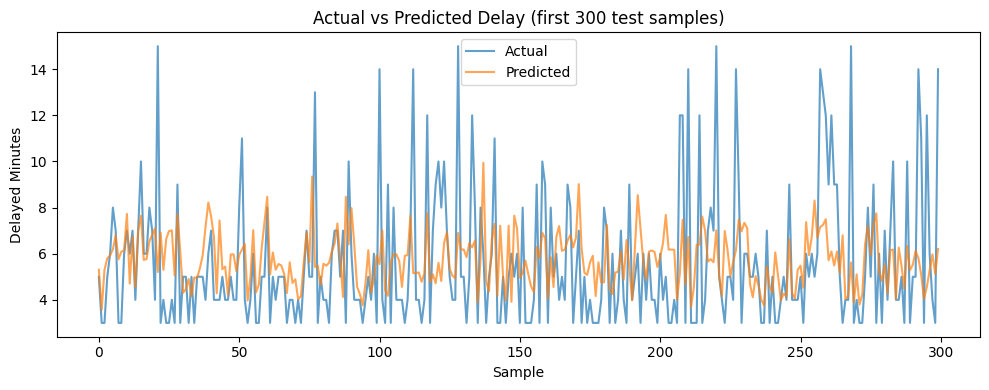

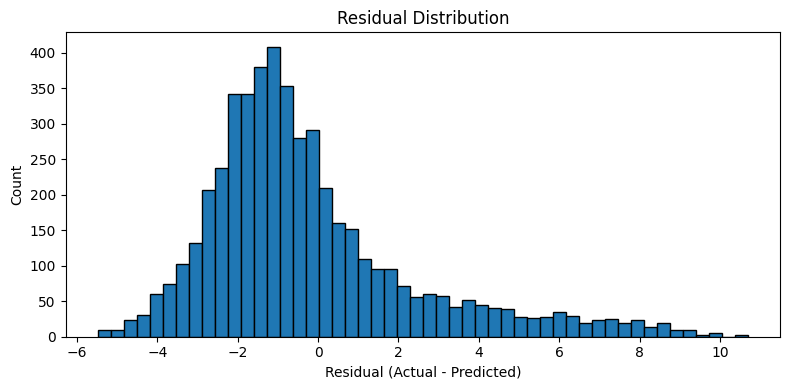

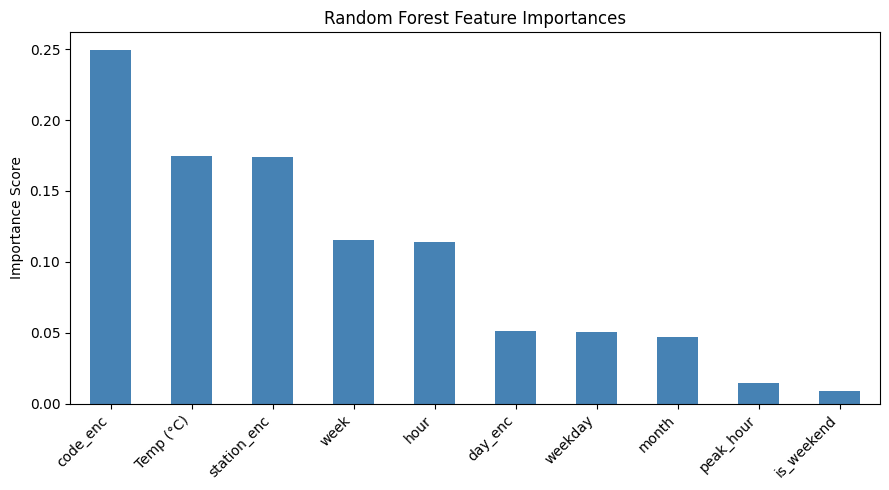

In [ ]:
## 9. VISUALIZATIONS

# --- 9a. Actual vs Predicted ---
# Plot the first 300 test samples to visually compare predictions to ground truth
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test.values[:300], label='Actual', alpha=0.7)    # True delay values
ax.plot(y_pred[:300],        label='Predicted', alpha=0.7) # Model's predictions
ax.set_title('Actual vs Predicted Delay (first 300 test samples)')
ax.set_xlabel('Sample')
ax.set_ylabel('Delayed Minutes')
ax.legend()
plt.tight_layout()
plt.show()

# --- 9b. Residuals ---
# Residuals = how wrong each prediction was (positive = underestimated, negative = overestimated)
# A good model has residuals centered near 0 with no strong skew
residuals = y_test.values - y_pred
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=50, edgecolor='black')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# --- 9c. Feature Importance (built-in Random Forest) ---
# feature_importances_ shows how much each feature contributed to reducing error
# Higher = more important to the model's decisions
feat_imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Random Forest Feature Importances')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




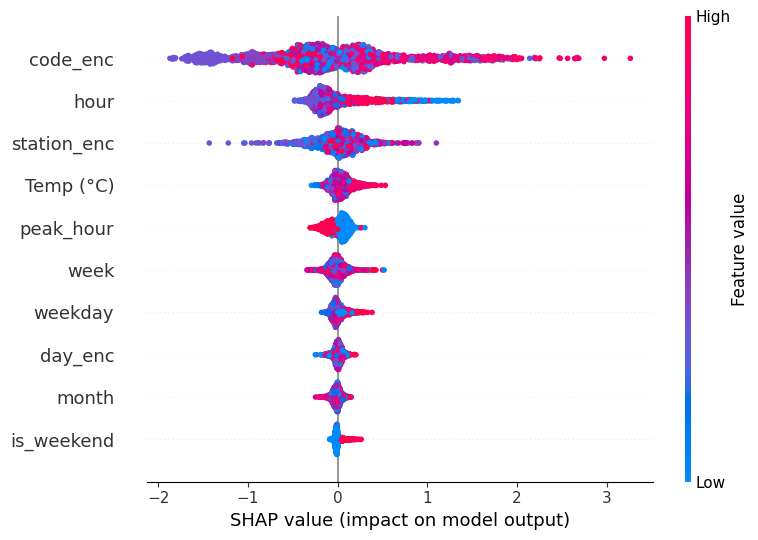

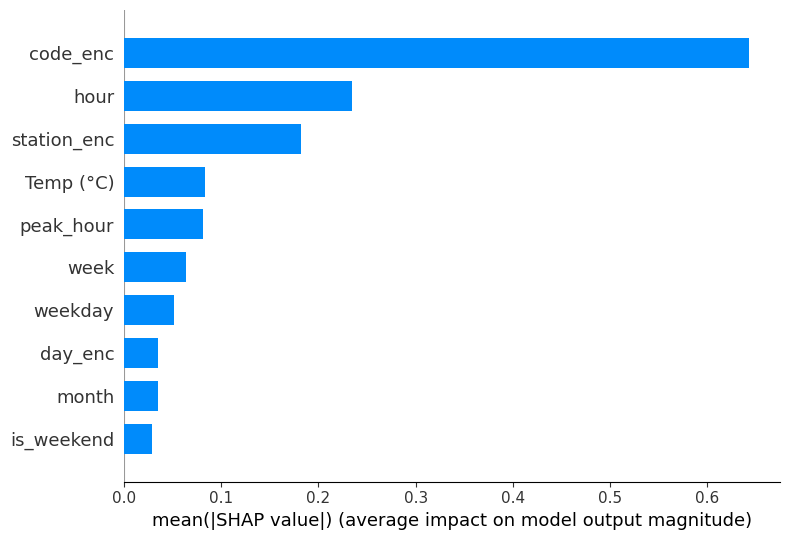

In [22]:
## 10. SHAP ANALYSIS
 
# SHAP explains WHY the model made each prediction
# by assigning each feature a contribution value (positive or negative)

# Sample 2000 rows from the test set for speed — SHAP is computationally expensive
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42).copy()

# Force all columns to float — SHAP requires purely numeric input
X_shap = X_shap.astype(float)

# TreeExplainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values — one value per feature per row
# Positive SHAP = pushed prediction higher, Negative = pushed prediction lower
shap_values = explainer.shap_values(X_shap)

# Summary plot: shows distribution of SHAP values for each feature
# Each dot is one prediction — color shows the feature value (red=high, blue=low)
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES)

# Bar plot: shows average absolute SHAP value per feature
# This is a cleaner version of overall feature importance
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, plot_type='bar')